In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Imposta lo stile per i grafici
plt.style.use('default')
sns.set_palette("husl")

def load_data(csv_path="../results/risultati.csv"):
    """Carica i dati dal CSV e gestisce i valori infiniti"""
    df = pd.read_csv(csv_path)
    
    # Sostituisci inf con NaN per facilitare l'analisi
    df = df.replace([np.inf, -np.inf], np.nan)
    
    print(f"Dataset caricato: {len(df)} righe")
    print(f"Funzioni uniche: {df['Funzione'].nunique()}")
    print(f"Dimensioni testate: {sorted(df['Dimensioni'].unique())}")
    
    return df

def plot_convergence_heatmap(df):
    """Crea una heatmap che mostra i problemi di convergenza"""
    # Crea una matrice pivot per la convergenza
    convergence_issues = df.groupby(['Funzione', 'Dimensioni']).apply(
        lambda x: x[['Mean', 'RMSE']].isna().any().any()
    ).unstack(fill_value=False)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(convergence_issues, annot=True, cmap='RdYlBu_r', 
                cbar_kws={'label': 'Problemi di convergenza'})
    plt.title('Problemi di Convergenza per Funzione e Dimensione', fontsize=14)
    plt.xlabel('Dimensioni')
    plt.ylabel('Funzione')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_performance_by_dimension(df):
    """Grafico delle prestazioni in base alle dimensioni"""
    # Filtra i dati validi (senza inf/nan)
    df_valid = df.dropna(subset=['Mean', 'RMSE'])
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # RMSE per dimensione
    axes[0,0].boxplot([df_valid[df_valid['Dimensioni'] == d]['RMSE'].values 
                      for d in sorted(df_valid['Dimensioni'].unique())], 
                     labels=sorted(df_valid['Dimensioni'].unique()))
    axes[0,0].set_title('Distribuzione RMSE per Dimensione')
    axes[0,0].set_xlabel('Dimensioni')
    axes[0,0].set_ylabel('RMSE')
    axes[0,0].set_yscale('log')
    
    # Tempo di esecuzione per dimensione
    axes[0,1].boxplot([df_valid[df_valid['Dimensioni'] == d]['Tempo medio (s)'].values 
                      for d in sorted(df_valid['Dimensioni'].unique())], 
                     labels=sorted(df_valid['Dimensioni'].unique()))
    axes[0,1].set_title('Tempo di Esecuzione per Dimensione')
    axes[0,1].set_xlabel('Dimensioni')
    axes[0,1].set_ylabel('Tempo (s)')
    axes[0,1].set_yscale('log')
    
    # Scatter: Dimensioni vs RMSE
    for func in df_valid['Funzione'].unique()[:10]:  # Prime 10 funzioni
        func_data = df_valid[df_valid['Funzione'] == func]
        axes[1,0].scatter(func_data['Dimensioni'], func_data['RMSE'], 
                         label=func, alpha=0.7)
    axes[1,0].set_xlabel('Dimensioni')
    axes[1,0].set_ylabel('RMSE')
    axes[1,0].set_yscale('log')
    axes[1,0].set_title('RMSE vs Dimensioni (prime 10 funzioni)')
    axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Scatter: Tempo vs RMSE
    axes[1,1].scatter(df_valid['Tempo medio (s)'], df_valid['RMSE'], alpha=0.6)
    axes[1,1].set_xlabel('Tempo medio (s)')
    axes[1,1].set_ylabel('RMSE')
    axes[1,1].set_xscale('log')
    axes[1,1].set_yscale('log')
    axes[1,1].set_title('Tempo vs RMSE')
    
    plt.tight_layout()
    plt.show()

def plot_function_comparison(df, metric='RMSE'):
    """Confronta le prestazioni delle diverse funzioni"""
    df_valid = df.dropna(subset=[metric])
    
    # Calcola statistiche aggregate per funzione
    func_stats = df_valid.groupby('Funzione')[metric].agg(['mean', 'std', 'count']).reset_index()
    func_stats = func_stats.sort_values('mean')
    
    plt.figure(figsize=(14, 8))
    
    # Bar plot con error bars
    x_pos = np.arange(len(func_stats))
    bars = plt.bar(x_pos, func_stats['mean'], yerr=func_stats['std'], 
                   capsize=5, alpha=0.7, color='skyblue', edgecolor='navy')
    
    # Aggiungi il numero di test sopra ogni barra
    for i, (bar, count) in enumerate(zip(bars, func_stats['count'])):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + func_stats['std'].iloc[i],
                f'n={count}', ha='center', va='bottom', fontsize=8)
    
    plt.xlabel('Funzioni')
    plt.ylabel(f'{metric} (scala log)')
    plt.title(f'Confronto {metric} tra Funzioni (media ± std)')
    plt.xticks(x_pos, func_stats['Funzione'], rotation=45, ha='right')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_convergence_rate(df):
    """Analizza il tasso di convergenza"""
    # Calcola il tasso di convergenza per funzione e dimensione
    convergence_stats = df.groupby(['Funzione', 'Dimensioni']).apply(
        lambda x: (~x[['Mean', 'RMSE']].isna().any(axis=1)).mean()
    ).reset_index()
    convergence_stats.columns = ['Funzione', 'Dimensioni', 'Tasso_Convergenza']
    
    # Pivot per la heatmap
    pivot_conv = convergence_stats.pivot(index='Funzione', 
                                        columns='Dimensioni', 
                                        values='Tasso_Convergenza')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_conv, annot=True, cmap='RdYlGn', 
                vmin=0, vmax=1, fmt='.2f',
                cbar_kws={'label': 'Tasso di Convergenza'})
    plt.title('Tasso di Convergenza per Funzione e Dimensione', fontsize=14)
    plt.xlabel('Dimensioni')
    plt.ylabel('Funzione')
    plt.tight_layout()
    plt.show()

def plot_best_performers(df, top_n=10):
    """Identifica e visualizza le migliori performance"""
    df_valid = df.dropna(subset=['RMSE'])
    
    # Top performers per RMSE più basso
    best_rmse = df_valid.nsmallest(top_n, 'RMSE')
    
    # Top performers per tempo più veloce
    best_time = df_valid.nsmallest(top_n, 'Tempo medio (s)')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Migliori RMSE
    axes[0].barh(range(len(best_rmse)), best_rmse['RMSE'])
    axes[0].set_yticks(range(len(best_rmse)))
    axes[0].set_yticklabels([f"{row['Funzione']}\n({row['Dimensioni']}D)" 
                            for _, row in best_rmse.iterrows()])
    axes[0].set_xlabel('RMSE')
    axes[0].set_title(f'Top {top_n} Migliori RMSE')
    axes[0].set_xscale('log')
    
    # Migliori tempi
    axes[1].barh(range(len(best_time)), best_time['Tempo medio (s)'])
    axes[1].set_yticks(range(len(best_time)))
    axes[1].set_yticklabels([f"{row['Funzione']}\n({row['Dimensioni']}D)" 
                            for _, row in best_time.iterrows()])
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_title(f'Top {top_n} Tempi più Veloci')
    
    plt.tight_layout()
    plt.show()

def print_summary_statistics(df):
    """Stampa statistiche riassuntive"""
    print("=== STATISTICHE RIASSUNTIVE ===\n")
    
    # Problemi di convergenza
    total_tests = len(df)
    failed_tests = df[['Mean', 'RMSE']].isna().any(axis=1).sum()
    success_rate = (total_tests - failed_tests) / total_tests * 100
    
    print(f"Test totali: {total_tests}")
    print(f"Test falliti (convergenza): {failed_tests}")
    print(f"Tasso di successo: {success_rate:.1f}%\n")
    
    # Funzioni più problematiche
    failed_by_function = df.groupby('Funzione').apply(
        lambda x: x[['Mean', 'RMSE']].isna().any(axis=1).sum()
    ).sort_values(ascending=False)
    
    print("FUNZIONI PIÙ PROBLEMATICHE:")
    for func, failures in failed_by_function.head().items():
        total_func_tests = len(df[df['Funzione'] == func])
        print(f"- {func}: {failures}/{total_func_tests} fallimenti")
    
    print("\n" + "="*50)
    
    # Statistiche per dati validi
    df_valid = df.dropna(subset=['RMSE'])
    if len(df_valid) > 0:
        print("\nSTATISTICHE DATI VALIDI:")
        print(f"RMSE - Media: {df_valid['RMSE'].mean():.2e}")
        print(f"RMSE - Mediana: {df_valid['RMSE'].median():.2e}")
        print(f"Tempo - Media: {df_valid['Tempo medio (s)'].mean():.2f}s")
        print(f"Tempo - Mediana: {df_valid['Tempo medio (s)'].median():.2f}s")

# Funzione principale per eseguire tutta l'analisi
def run_complete_analysis(csv_path="../results/risultati.csv"):
    """Esegue l'analisi completa dei risultati"""
    print("Caricamento dati...")
    df = load_data(csv_path)
    
    print("\nStatistiche generali...")
    print_summary_statistics(df)
    
    print("\nGenerazione grafici...")
    
    print("1. Heatmap problemi di convergenza...")
    plot_convergence_heatmap(df)
    
    print("2. Performance per dimensione...")
    plot_performance_by_dimension(df)
    
    print("3. Confronto tra funzioni...")
    plot_function_comparison(df, 'RMSE')
    
    print("4. Tasso di convergenza...")
    plot_convergence_rate(df)
    
    print("5. Migliori performance...")
    plot_best_performers(df)
    
    print("\nAnalisi completata!")

Caricamento dati...
Dataset caricato: 102 righe
Funzioni uniche: 30
Dimensioni testate: [2, 4, 10, 30, 50, 100]

Statistiche generali...
=== STATISTICHE RIASSUNTIVE ===

Test totali: 102
Test falliti (convergenza): 12
Tasso di successo: 88.2%

FUNZIONI PIÙ PROBLEMATICHE:
- Modified Inverted DTLZ7: 5/5 fallimenti
- Schwefel 2.22: 4/5 fallimenti
- Powell Sum: 2/5 fallimenti
- Zakharov: 1/5 fallimenti
- Alpine1: 0/5 fallimenti


STATISTICHE DATI VALIDI:
RMSE - Media: 9.61e+132
RMSE - Mediana: 1.05e+03
Tempo - Media: 35.73s
Tempo - Mediana: 5.55s

Generazione grafici...
1. Heatmap problemi di convergenza...


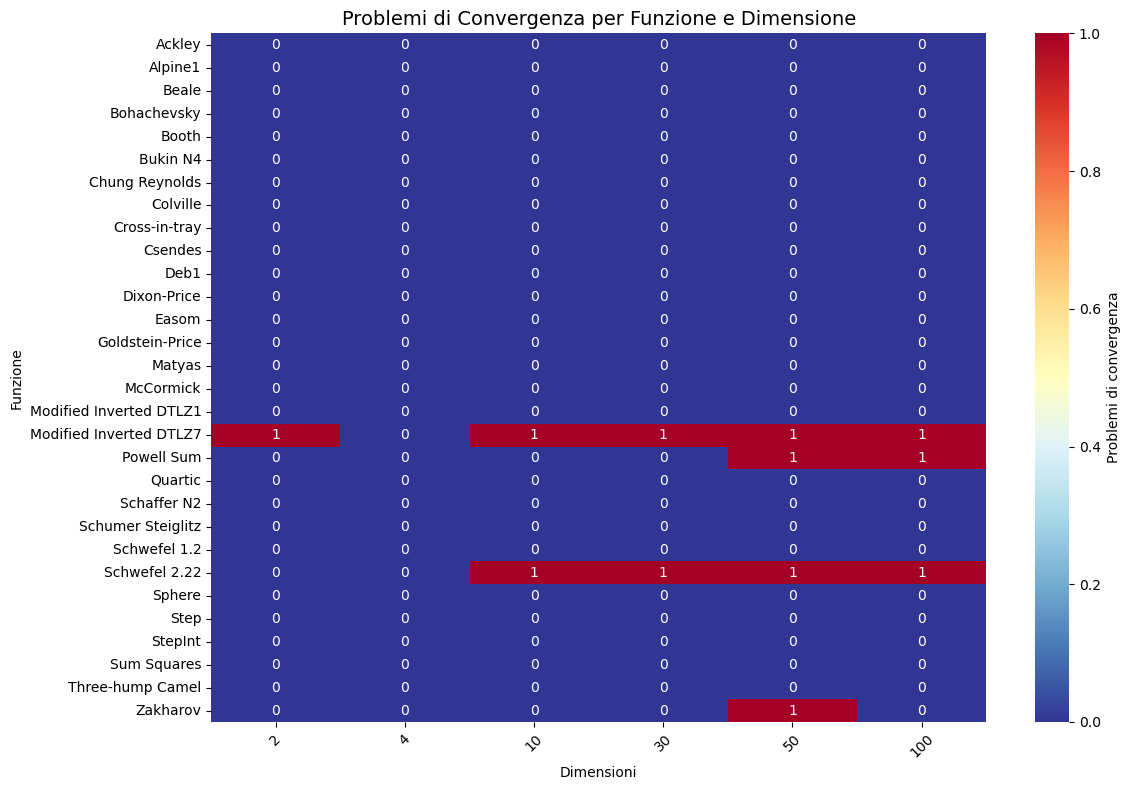

2. Performance per dimensione...


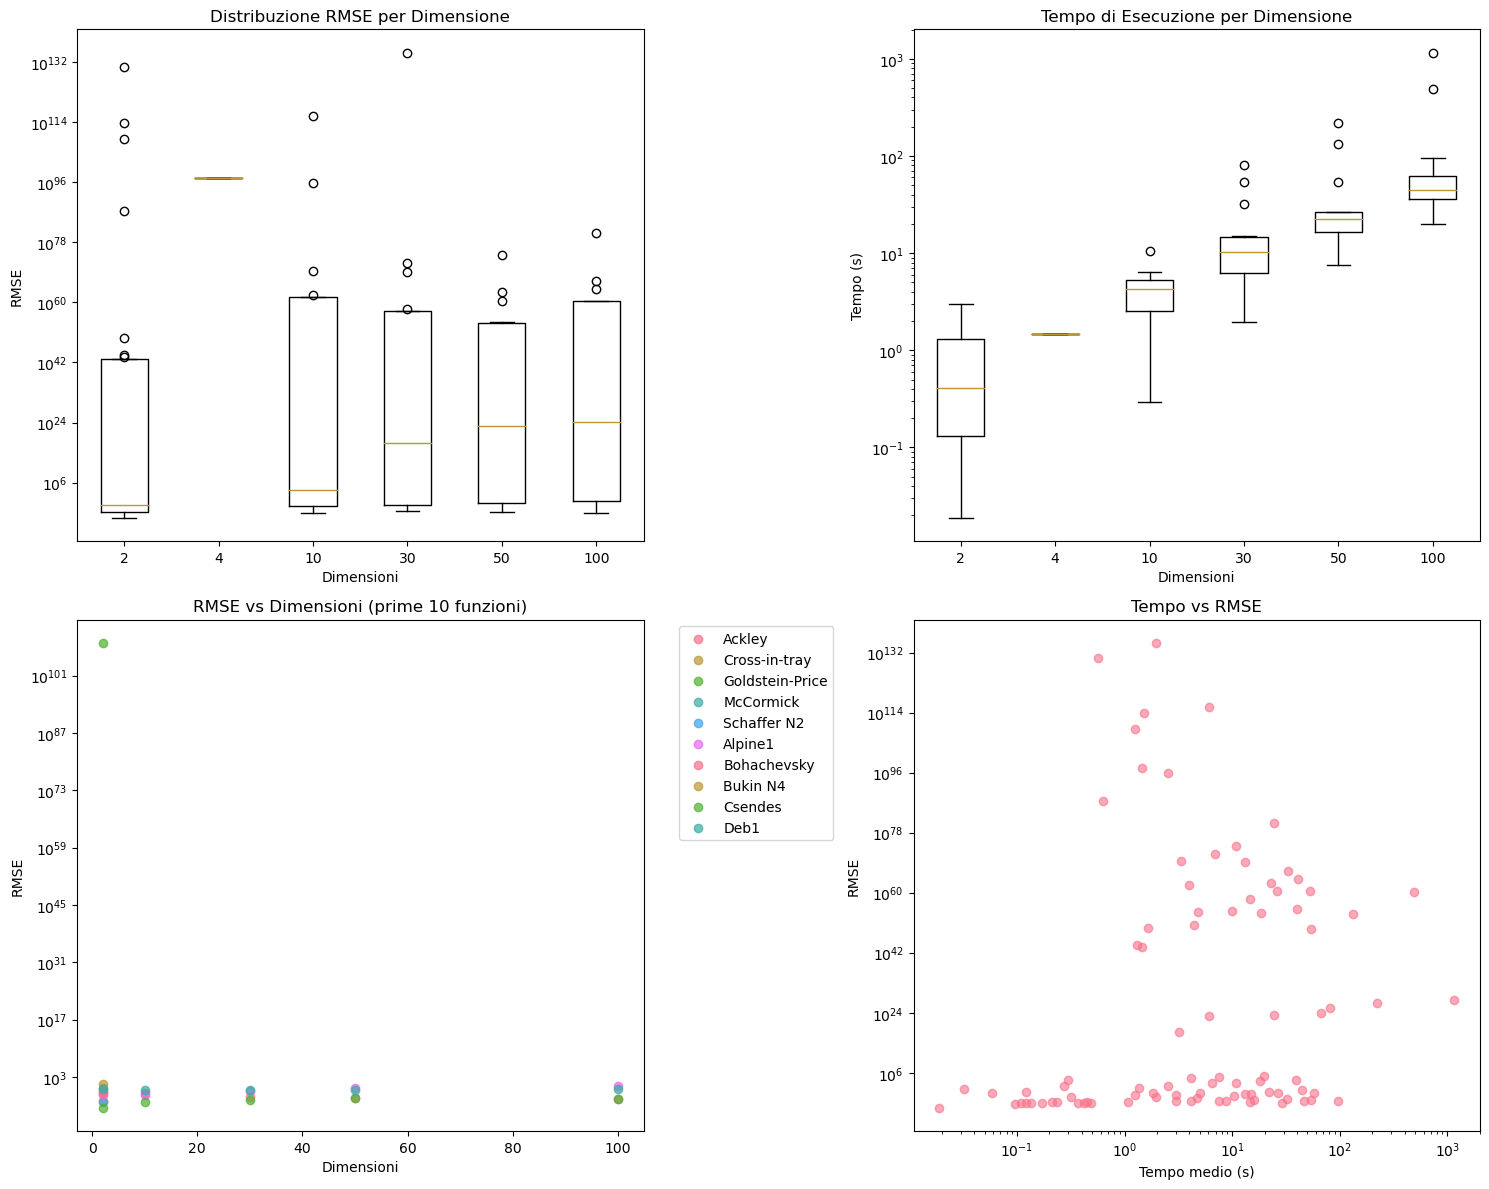

3. Confronto tra funzioni...


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


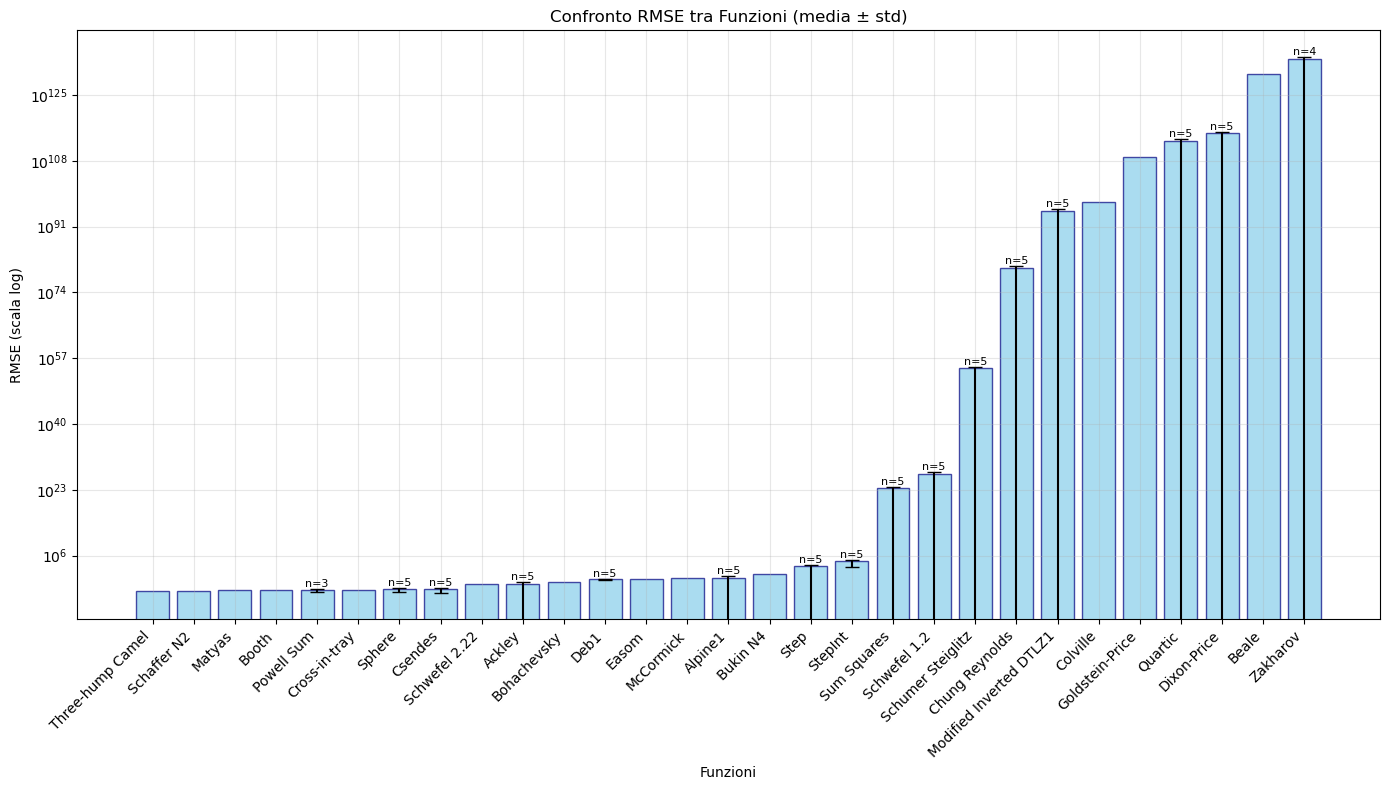

4. Tasso di convergenza...


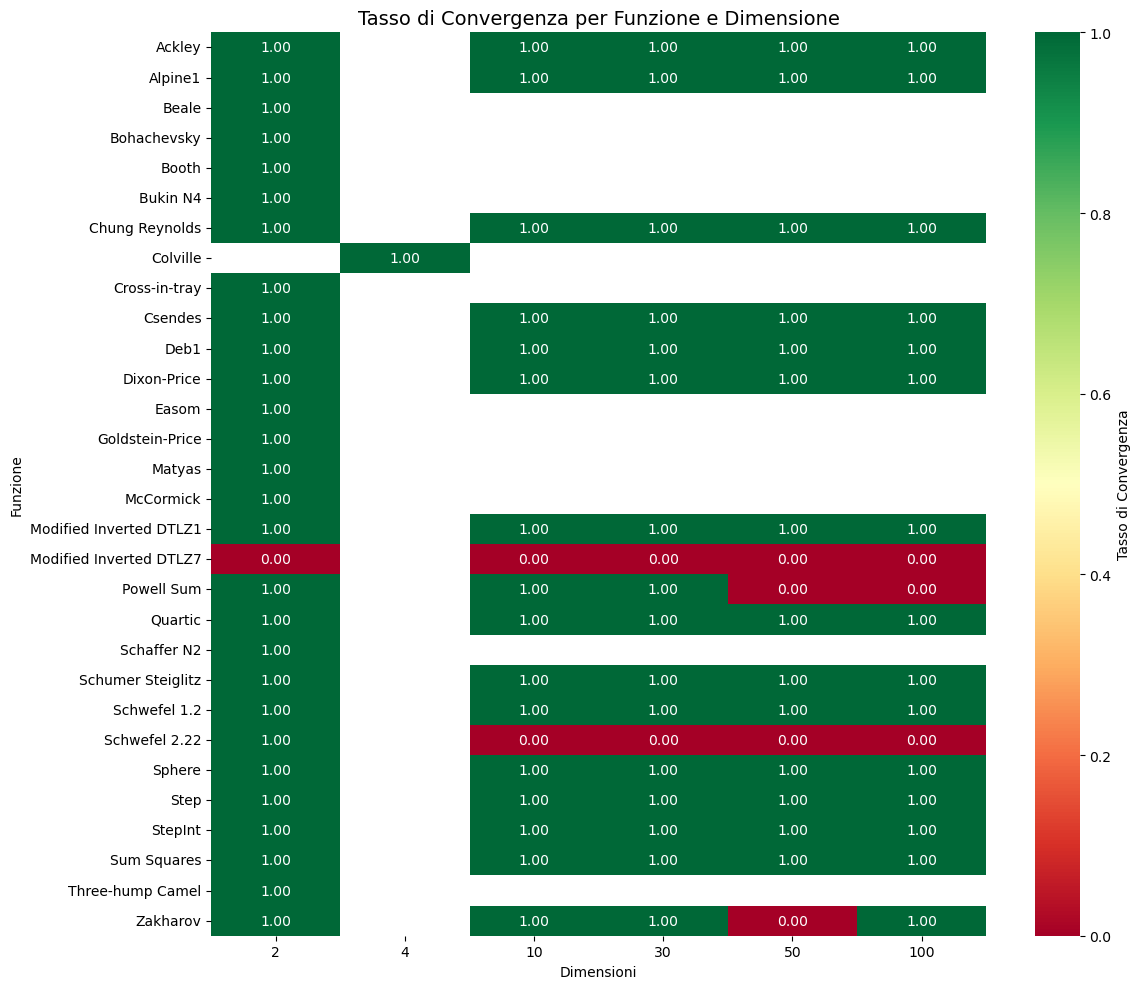

5. Migliori performance...


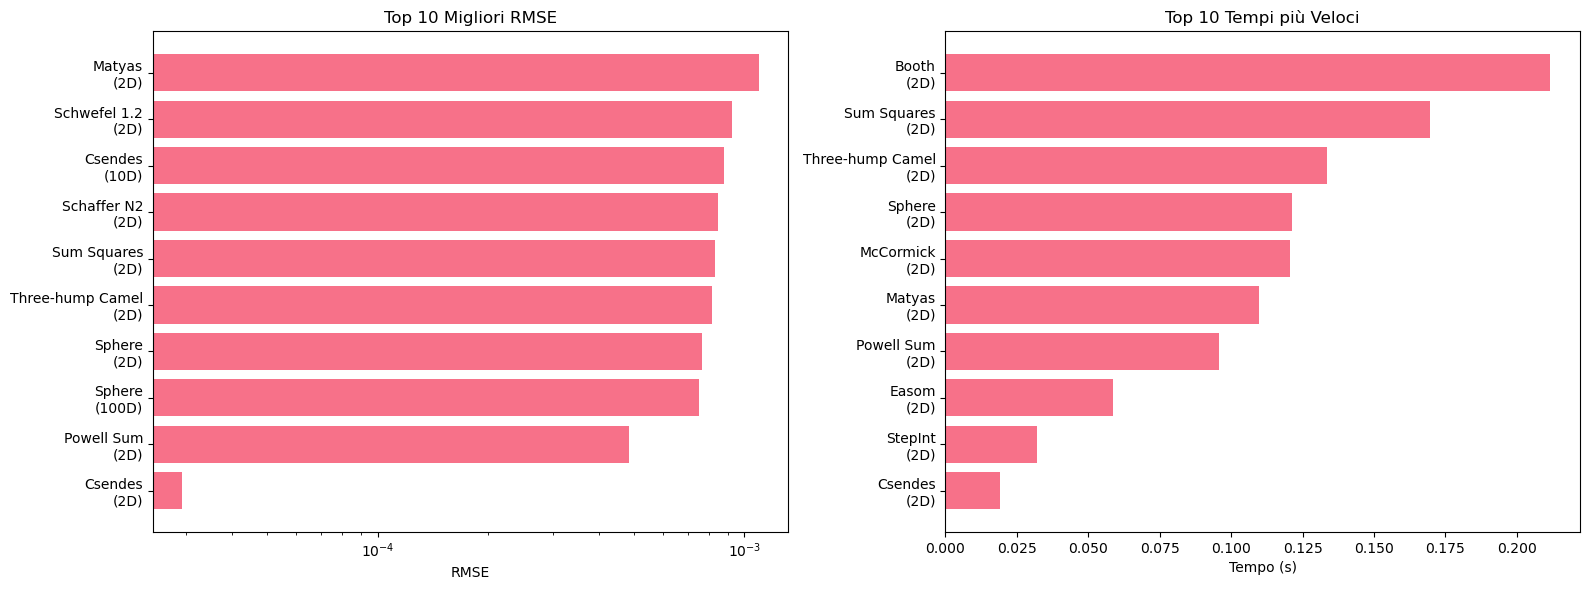


Analisi completata!


In [2]:
# Esegui l'analisi completa
if __name__ == "__main__":
    run_complete_analysis()